# Monte Carlo portfolio simulation

Load the portfolio config and historical prices, then project the portfolio forward with a block bootstrap of historical monthly returns.


In [1]:
import pandas as pd

from portfolio_lab.analysis import (
    annualised_stats,
    contributed_path,
    contributions_by_asset,
    final_value_summary,
    gain_by_asset,
    gain_summary,
    history_window,
    monthly_returns_from_prices,
    plot_fan_chart,
    plot_final_histogram,
    plot_gain_fan_chart,
    plot_sequence_risk,
    plot_weights_over_time,
    portfolio_return_series,
    run_simulation,
    save_figure,
    sensitivity_to_haircut,
    sequence_risk_scenarios,
    sequence_risk_summary,
    weights_summary,
)
from portfolio_lab.config import load_config
from portfolio_lab.data import load_prices

## Configuration

Assets and simulation settings from `config/portfolio.toml` (falls back to the example file if missing).


In [2]:
cfg = load_config()

display(pd.DataFrame([a.model_dump() for a in cfg.portfolio.assets]))
print(cfg.portfolio.name, cfg.portfolio.currency)
print(cfg.simulation)

13:49:21 | INFO     | portfolio_lab.config | Loaded config from /home/alexrr/Projects/idontknowmoney/portfolio-lab/config/portfolio.toml


,name,isin,ticker,contribution_weight,initial_value,cost_basis
0,MSCI World,IE00B4L5Y983,EUNL.DE,0.755556,1301.41,1200.00
1,Emerging Markets IMI,IE00BKM4GZ66,IS3N.DE,0.100000,151.17,140.00
2,MSCI Europe,IE00B4K48X80,EUNK.DE,0.144444,216.99,210.00
3,Physical Gold,IE00B4ND3602,PPFB.DE,0.000000,672.53,750.05


Global indexed EUR
monthly_contribution=450.0 horizon_years=10 n_paths=30000 block_size=3 seed=42 rebalance='none'


## Historical data

Daily prices for every asset, cached in `data/raw/`, converted to monthly returns. Only dates where all assets have data are kept, so the shortest history sets the window.


In [3]:
tickers = [a.ticker for a in cfg.portfolio.assets]
prices = load_prices(tickers)
returns = monthly_returns_from_prices(prices, tickers)

print(f"{returns.index[0]:%Y-%m} to {returns.index[-1]:%Y-%m} ({len(returns)} months)")
display(history_window(prices, tickers, cfg.simulation.block_size))
annualised_stats(returns).round(3)

13:49:21 | INFO     | portfolio_lab.data | Loaded prices from local file.


2021-08 to 2026-10 (63 months)


,First price,Months,Distinct blocks
Ticker,,,
EUNL.DE,2009-09-25,205,203
IS3N.DE,2014-06-11,148,146
EUNK.DE,2009-10-20,204,202
PPFB.DE,2021-07-16,63,61
Common window,2021-07-16,63,61


,ann. mean,ann. vol
Ticker,,
EUNL.DE,0.122,0.130
IS3N.DE,0.097,0.145
EUNK.DE,0.096,0.124
PPFB.DE,0.177,0.143


## Simulation

Block bootstrap: each path stitches together 12-month blocks of historical returns. The monthly contribution is split by `contribution_weight` and added at the start of each month.


In [4]:
paths = run_simulation(cfg, returns)  # (n_paths, n_months + 1, n_assets)
total = paths.sum(axis=2)
contributed = contributed_path(cfg, start="initial_value")
cost = contributed_path(cfg, start="cost_basis")
total.shape

(30000, 121)

## Results


In [5]:
summary = final_value_summary(total, contributed, cost)
summary.to_frame(f"Final value ({cfg.portfolio.currency})").map("{:,.2f}".format)

,Final value (EUR)
P5,"77,465.89"
P10,"83,449.27"
P25,"94,422.84"
P50,"108,101.95"
P75,"124,131.50"
P95,"151,226.87"
Contributed,"56,342.10"
P(loss),0.00
Cost basis + contrib.,"56,300.05"
P(loss vs cost),0.00


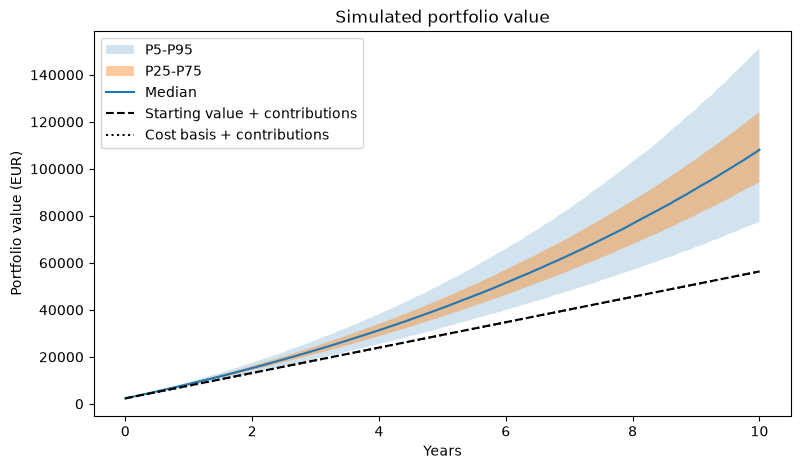

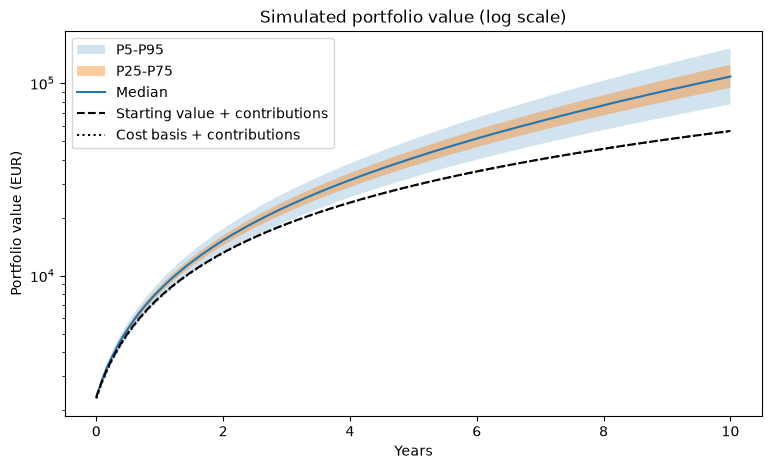

In [6]:
currency = cfg.portfolio.currency
fan = plot_fan_chart(total, contributed, currency, cost=cost)
fan_log = plot_fan_chart(total, contributed, currency, log_scale=True, cost=cost)
save_figure(fan, "fan_chart")
save_figure(fan_log, "fan_chart_log");

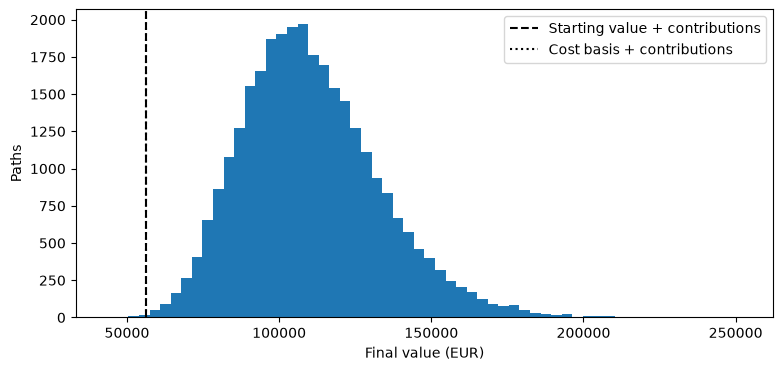

In [7]:
hist = plot_final_histogram(total, contributed, cfg.portfolio.currency, cost=cost)
save_figure(hist, "final_value_histogram");

### Asset weights over time

How the portfolio weights evolve over time. If the portfolio is rebalanced, the weights will converge to the target weights. If not, they will drift with the relative performance of each asset.


,Start,P5,P50,P95
MSCI World,55.6%,67.5%,75.1%,80.7%
Emerging Markets IMI,6.5%,6.4%,8.3%,10.8%
MSCI Europe,9.3%,9.4%,12.6%,16.9%
Physical Gold,28.7%,1.5%,3.6%,8.0%


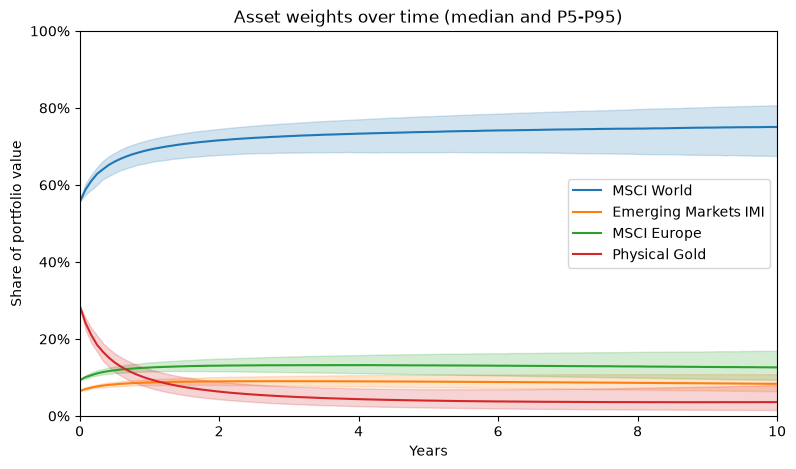

In [8]:
asset_names = [a.name for a in cfg.portfolio.assets]
display(weights_summary(paths, asset_names).map("{:.1%}".format))

weights_fig = plot_weights_over_time(paths, asset_names)
save_figure(weights_fig, "asset_weights");

## Sensitivity to the history window

The resampled window is short and mostly a bull market (see the table above: the youngest ETF sets the start, and the number of distinct blocks is small), so the baseline is likely flattering. As a stress check, subtract a flat annual haircut from every historical return and re-run. P(loss) is the share of paths ending below the total contributed.


In [9]:
sens = sensitivity_to_haircut(cfg, returns)
sens.assign(**{c: sens[c].map("{:,.0f}".format) for c in ["P5", "P50", "P95"]}).assign(
    **{"P(loss)": sens["P(loss)"].map("{:.1%}".format)}
)

,P5,P50,P95,P(loss)
Baseline,"77,466","108,102","151,227",0.1%
-2%/yr,"68,948","95,608","133,068",0.4%
-4%/yr,"61,597","84,861","117,327",1.8%


## Sequence risk

Same returns, different order. Take the portfolio's historical monthly return series and replay it three other ways: reversed, with the worst 12-month block moved to the start, and with it moved to the end. Every scenario has exactly the same returns, yet the final values differ once you contribute every month: a crash late in the horizon hits a large pot, while an early one only hits a small one.


Without contributions the order would not matter (multiplication commutes), so the gap below is entirely due to the monthly contributions.


In [10]:
port_returns = portfolio_return_series(cfg, returns)
initial_total = sum(a.initial_value for a in cfg.portfolio.assets)
monthly = cfg.simulation.monthly_contribution

scenarios = sequence_risk_scenarios(port_returns, initial_total, monthly, window=12)
seq_summary = sequence_risk_summary(scenarios)
seq_summary.map("{:,.2f}".format).to_frame()

,Final value
Historical order,"48,486.78"
Reversed,"42,758.49"
Worst block first,"49,628.54"
Worst block last,"41,396.40"


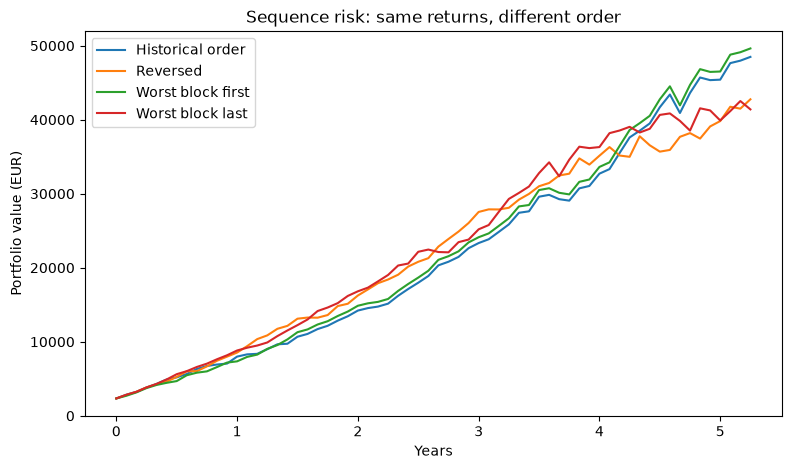

In [11]:
seq_fig = plot_sequence_risk(scenarios, cfg.portfolio.currency)
save_figure(seq_fig, "sequence_risk");

## Gain vs cost basis

How much the portfolio is worth compared with what was actually paid: `cost_basis` per asset plus the monthly contributions. Gain = simulated value − (cost basis + contributions).


In [12]:
gains = gain_summary(total, cost)
gains.map(lambda v: f"{v:,.2f}").assign(Return=gains["Return"].map("{:.1%}".format))

,Gain,Return
P5,"21,165.84",37.6%
P10,"27,149.22",48.2%
P25,"38,122.79",67.7%
P50,"51,801.90",92.0%
P75,"67,831.45",120.5%
P95,"94,926.82",168.6%


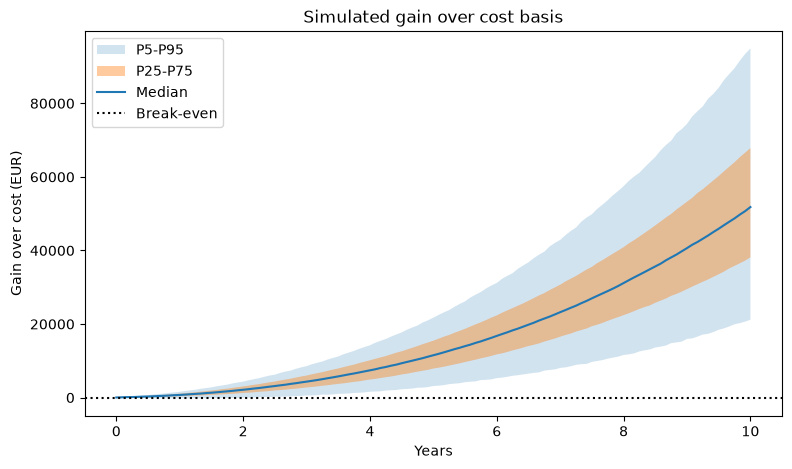

In [13]:
gain_fig = plot_gain_fan_chart(total, cost, cfg.portfolio.currency)
save_figure(gain_fig, "gain_fan_chart");

### Per asset

Final gain for each asset against its own cost basis plus its share of the contributions.


In [14]:
by_asset = gain_by_asset(
    paths, contributions_by_asset(cfg, "cost_basis"), [a.name for a in cfg.portfolio.assets]
)

formatted_by_asset = pd.DataFrame(
    {
        col: values.map("{:.1%}".format if col == "P50 return" else "{:,.2f}".format)
        for col, values in by_asset.items()
    }
)

formatted_by_asset

,Invested,P50 return,P5 gain,P10 gain,P25 gain,P50 gain,P75 gain,P95 gain
MSCI World,"42,000.00",92.5%,"12,783.27","17,806.03","27,016.07","38,856.77","52,671.09","76,436.89"
Emerging Markets IMI,"5,540.00",62.1%,609.00,"1,125.43","2,105.54","3,440.77","5,013.42","8,037.66"
MSCI Europe,"8,010.00",69.9%,"1,833.83","2,552.69","3,893.41","5,597.22","7,584.53","10,967.18"
Physical Gold,750.05,415.1%,"1,067.76","1,383.53","2,059.86","3,113.76","4,537.33","7,433.75"
